[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Time-Series-Analysis/blob/main/notebooks/EN/chapter1_lecture_notebook.ipynb)

# Time Series Analysis — Chapter 1: Stochastic processes and stationarity

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- Four real series: Romanian GDP and inflation, EUR/RON, BET returns.
- Stochastic processes by simulation: ensembles, stationarity, white noise, the random walk.
- The lag operator, differencing, the Wold decomposition, ergodicity.
- Sample ACF and PACF with confidence bands; the Box–Pierce and Ljung–Box tests.
- Transformations: log, differences, Box–Cox (Guerrero's lambda); over-differencing; the Nile and the sunspots.
- References: Huang and Petukhina (2022), *Applied Time Series Analysis and Forecasting with Python*, Ch. 1–2; Hyndman and Athanasopoulos, *Forecasting: Principles and Practice* (3rd ed.), Ch. 2–3; Brockwell and Davis (2016), Ch. 1.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/TSA/Chapter_1'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/TSA - Serii de timp/repo/notebooks/EN


In [2]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [3]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import tsa_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the TSA repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [4]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the TSA repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Definitions used in the whole notebook

- Sample ACF with divisor $T$: $\hat\rho(h) = \sum_{t=1}^{T-h}(x_t - \bar x)(x_{t+h} - \bar x)/\sum_{t=1}^{T}(x_t - \bar x)^2$; 95% band $\pm 1.96/\sqrt{T}$.
- Ljung–Box: $Q^*(m) = T(T+2)\sum_{h=1}^{m}\hat\rho(h)^2/(T-h)$, approximately $\chi^2(m)$ under white noise.
- Helpers: `sample_acf`, `sample_pacf`, `ljung_box`, `acf_bars` (a correlogram with its band), `simulate_arma`.

In [5]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
SEED = 2026
GDP_REAL = ('namq_10_gdp', 'Q.CLV10_MEUR.NSA.B1GQ.RO')
GDP_NOMINAL = ('namq_10_gdp', 'Q.CP_MEUR.NSA.B1GQ.RO')
HICP = ('prc_hicp_minr', 'M.I15.TOTAL.RO')
START = '2000-01-01'
BAND_COL = st.IDAred
NAME = {'bet': 'BET', 'sp500': 'S&P 500'}


def ro_gdp(kind='real'):
    """Romanian quarterly GDP (Eurostat), million EUR, not seasonally adjusted: 'real' or 'nominal'."""
    ds, key = GDP_REAL if kind == 'real' else GDP_NOMINAL
    return read_eurostat(ds, key).rename(f'gdp_{kind}')


def ro_hicp():
    """Romanian HICP (Eurostat, monthly, 2015 = 100)."""
    return read_eurostat(*HICP).rename('hicp')


def sample_acf(x, nlags=20):
    """Sample ACF rho(1..nlags) with the divisor T (as in Brockwell and Davis)."""
    return acf(np.asarray(x, float), nlags=nlags, fft=True)[1:]


def sample_pacf(x, nlags=20):
    """Sample PACF phi_hh, h = 1..nlags (Durbin-Levinson on the sample ACF)."""
    return pacf(np.asarray(x, float), nlags=nlags, method='ywm')[1:]


def ljung_box(x, m=10):
    """Ljung-Box Q*(m) and Box-Pierce Q(m) with their chi-square(m) p-values."""
    t = acorr_ljungbox(np.asarray(x, float), lags=[m], boxpierce=True, return_df=True).iloc[0]
    return {'lb': float(t['lb_stat']), 'lb_p': float(t['lb_pvalue']), 'bp': float(t['bp_stat']), 'bp_p': float(t['bp_pvalue'])}


def acf_bars(ax, r, T, color=st.MainBlue, theory=None, label='sample ACF', band=True):
    """ACF as bars at lags 1..len(r), with the +-1.96/sqrt(T) bands and optional theoretical values."""
    lags = np.arange(1, len(r) + 1)
    ax.bar(lags, r, width=0.55, color=color, label=label)
    if theory is not None:
        ax.plot(lags, theory, 'o', ms=4, color=st.Orange, label='theoretical ACF')
    if band:
        b = 1.96 / np.sqrt(T)
        ax.axhline(b, color=BAND_COL, ls='--', lw=0.9, label=r'$\pm 1.96/\sqrt{T}$')
        ax.axhline(-b, color=BAND_COL, ls='--', lw=0.9, label='_nolegend_')
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_xlim(0.3, len(r) + 0.7)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))


def simulate_arma(phi=(), theta=(), n=500, sigma=1.0, burn=500, rng=None):
    """X_t = sum phi_i X_{t-i} + e_t + sum theta_j e_{t-j}, e_t i.i.d. N(0, sigma^2), after a burn-in."""
    rng = rng if rng is not None else np.random.default_rng(SEED)
    e = rng.normal(0, sigma, n + burn)
    x = np.zeros(n + burn)
    p, q = len(phi), len(theta)
    for t in range(n + burn):
        x[t] = e[t] + sum(phi[i] * x[t - 1 - i] for i in range(p) if t - 1 - i >= 0) \
            + sum(theta[j] * e[t - 1 - j] for j in range(q) if t - 1 - j >= 0)
    return x[burn:]


def theoretical_acf(phi=(), theta=(), nlags=20):
    """Theoretical ACF of an ARMA process (statsmodels ArmaProcess), lags 1..nlags."""
    from statsmodels.tsa.arima_process import ArmaProcess
    return ArmaProcess(np.r_[1, -np.asarray(phi, float)], np.r_[1, np.asarray(theta, float)]).acf(nlags + 1)[1:]


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()

## 1. Four series of this course

- Romanian real GDP (Eurostat), HICP inflation (Eurostat), EUR/RON (BNR), BET daily log returns.

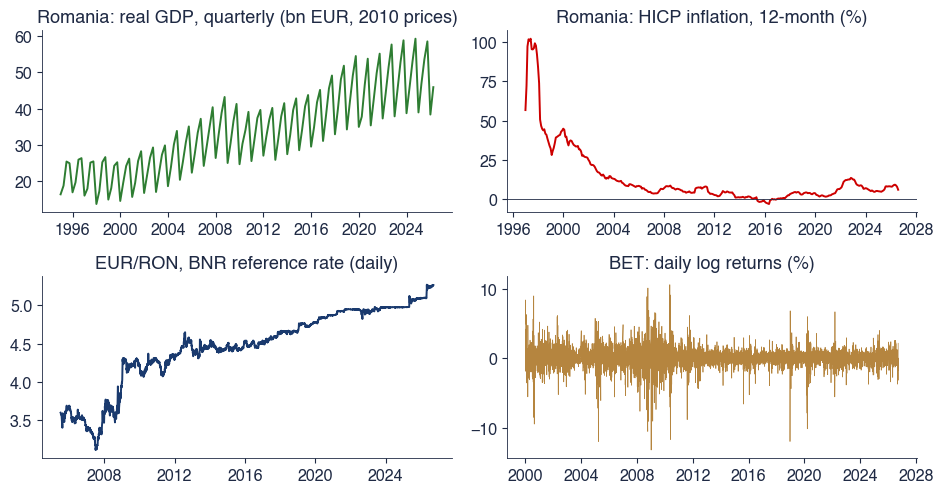

{'gdp_first': '1995-01-01',
 'gdp_last': '2026-04-01',
 'gdp_n': 126,
 'gdp_v0': 16.4738,
 'gdp_v1': 45.8798,
 'infl_first': '1997-01-01',
 'infl_last': '2026-08-01',
 'infl_max': 102.13889180446427,
 'infl_max_d': '1997-06-01',
 'infl_min': -3.0004237637526465,
 'infl_min_d': '2016-05-01',
 'infl_lastv': 6.085165825315464,
 'fx_first': '2005-07-04',
 'fx_v0': 3.5986,
 'fx_v1': 5.2644,
 'fx_n': 5353,
 'bet_n': 6670,
 'bet_sd': 1.3986385699937032,
 'bet_min': -13.116763290120481,
 'bet_min_d': '2009-01-07',
 'bet_max': 10.564511538205501,
 'bet_max_d': '2010-05-10',
 'bet_mean': 0.06393125538818989,
 'bet_mean_0': 0.07443677464049638,
 'bet_mean_1': 0.05398979086083946,
 'bet_sd_0': 3.62250019180609,
 'bet_sd_1': 0.6622018612804529}

In [6]:
def fig_four_series(save_it=True):
    """Four series of the course: Romanian real GDP, Romanian HICP inflation, EUR/RON, BET daily log returns."""
    gdp = ro_gdp('real') / 1000
    hicp = ro_hicp()
    infl = (100 * np.log(hicp).diff(12)).dropna()
    fx = load_close('eurron')
    bet = log_returns('bet', start=START)
    fig, ax = plt.subplots(2, 2, figsize=(9.6, 5.1))
    ax[0, 0].plot(gdp.index, gdp, color=st.Forest)
    ax[0, 0].set_title('Romania: real GDP, quarterly (bn EUR, 2010 prices)')
    ax[0, 1].plot(infl.index, infl, color=st.IDAred)
    ax[0, 1].axhline(0, color=st.DarkText, lw=0.6)
    ax[0, 1].set_title('Romania: HICP inflation, 12-month (%)')
    ax[1, 0].plot(fx.index, fx, color=st.MainBlue)
    ax[1, 0].set_title('EUR/RON, BNR reference rate (daily)')
    ax[1, 1].plot(bet.index, bet, color=st.Amber, lw=0.5)
    ax[1, 1].set_title('BET: daily log returns (%)')
    plt.tight_layout()
    save('tsa_ch1_four_series', save_it)
    out = {'gdp_first': gdp.index[0].strftime('%Y-%m-%d'), 'gdp_last': gdp.index[-1].strftime('%Y-%m-%d'),
           'gdp_n': int(len(gdp)), 'gdp_v0': float(gdp.iloc[0]), 'gdp_v1': float(gdp.iloc[-1]),
           'infl_first': infl.index[0].strftime('%Y-%m-%d'), 'infl_last': infl.index[-1].strftime('%Y-%m-%d'),
           'infl_max': float(infl.max()), 'infl_max_d': infl.idxmax().strftime('%Y-%m-%d'),
           'infl_min': float(infl.min()), 'infl_min_d': infl.idxmin().strftime('%Y-%m-%d'),
           'infl_lastv': float(infl.iloc[-1]),
           'fx_first': fx.index[0].strftime('%Y-%m-%d'), 'fx_v0': float(fx.iloc[0]), 'fx_v1': float(fx.iloc[-1]),
           'fx_n': int(len(fx)), 'bet_n': int(len(bet)), 'bet_sd': float(bet.std()), 'bet_min': float(bet.min()),
           'bet_min_d': bet.idxmin().strftime('%Y-%m-%d'), 'bet_max': float(bet.max()),
           'bet_max_d': bet.idxmax().strftime('%Y-%m-%d'), 'bet_mean': float(bet.mean()),
           'bet_mean_0': float(bet[:'2012'].mean()), 'bet_mean_1': float(bet['2013':].mean()),
           'bet_sd_0': float(bet['2008-09':'2009-03'].std()), 'bet_sd_1': float(bet['2017'].std())}
    return out


fig_four_series(save_it=False)

## 2. An ensemble of paths

- 40 paths of a stationary AR(1) and of a random walk; the band is $\pm 1.96$ standard deviations of $X_t$.

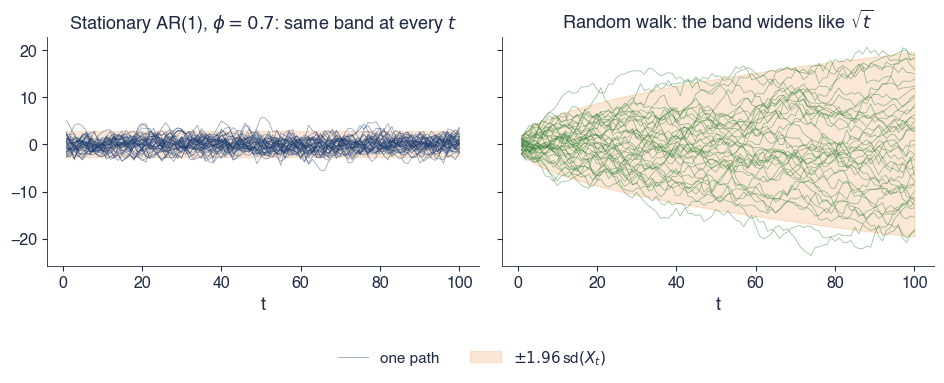

{'ar_var': 1.9607843137254901,
 'ar_sd': np.float64(1.4002800840280099),
 'rw_var_sim': 100.80083214622353,
 'n': 100,
 'paths': 40}

In [7]:
def fig_ensemble(n=100, paths=40, phi=0.7, save_it=True):
    """An ensemble of paths: stationary AR(1) and random walk, with the +-1.96 sd band of X_t."""
    rng = np.random.default_rng(SEED)
    fig, ax = plt.subplots(1, 2, figsize=(9.6, 3.4), sharey=True)
    t = np.arange(1, n + 1)
    sd_ar = 1 / np.sqrt(1 - phi ** 2)
    for i in range(paths):
        e = rng.normal(size=n)
        x = np.empty(n)
        x[0] = rng.normal(0, sd_ar)
        for k in range(1, n):
            x[k] = phi * x[k - 1] + e[k]
        ax[0].plot(t, x, color=st.MainBlue, lw=0.6, alpha=0.45, label='one path' if i == 0 else '_nolegend_')
        ax[1].plot(t, np.cumsum(rng.normal(size=n)), color=st.Forest, lw=0.6, alpha=0.45,
                   label='one path' if i == 0 else '_nolegend_')
    ax[0].fill_between(t, -1.96 * sd_ar, 1.96 * sd_ar, color=st.Orange, alpha=0.18, label=r'$\pm 1.96\,$sd$(X_t)$')
    ax[1].fill_between(t, -1.96 * np.sqrt(t), 1.96 * np.sqrt(t), color=st.Orange, alpha=0.18, label='_nolegend_')
    ax[0].set_title(rf'Stationary AR(1), $\phi = {phi}$: same band at every $t$')
    ax[1].set_title(r'Random walk: the band widens like $\sqrt{t}$')
    for a in ax:
        a.set_xlabel('t')
    st.fig_legend_bottom(fig, ncol=2, y=-0.01)
    plt.tight_layout()
    save('tsa_ch1_ensemble', save_it)
    # cross-sectional variance at t = n from many paths
    big = rng.normal(size=(5000, n))
    rw = big.cumsum(axis=1)
    return {'ar_var': 1 / (1 - phi ** 2), 'ar_sd': sd_ar, 'rw_var_sim': float(rw[:, -1].var()), 'n': n, 'paths': paths}


fig_ensemble(save_it=False)

## 3. Stationarity

- Four series that violate stationarity in different ways; a process that is weakly but not strictly stationary.

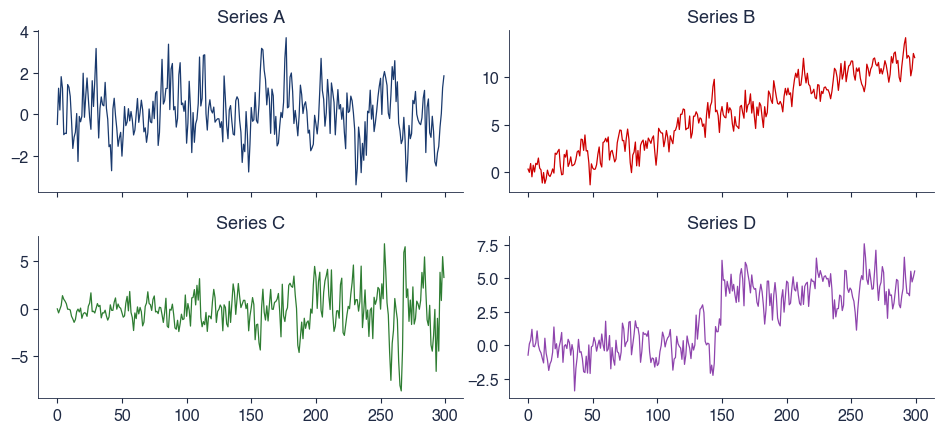

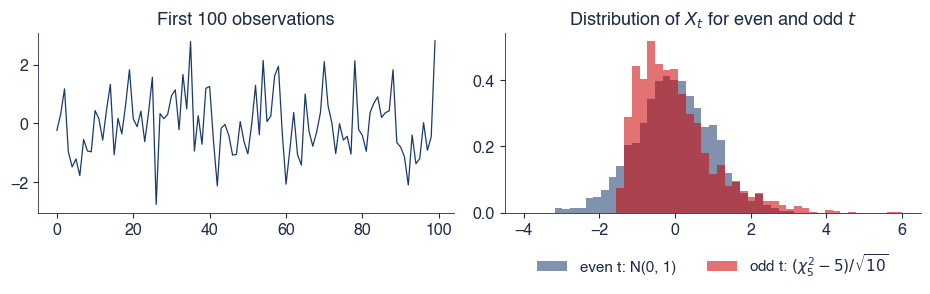

{'mean_e': -0.03205805662596629,
 'mean_o': -0.004838598992852048,
 'var_e': 0.9933907941046226,
 'var_o': 0.9988839149351957,
 'skew_e': -0.02278550872767992,
 'skew_o': 1.2987911022096457,
 'skew_th': 1.2649110640673518,
 'rho1': 0.0010768203797496504}

In [8]:
def fig_nonstationary(n=300, save_it=True):
    """Four series: stationary AR(1), linear trend, changing variance, level shift (room question)."""
    rng = np.random.default_rng(SEED + 1)
    t = np.arange(n)
    a = simulate_arma([0.5], n=n, rng=rng)
    b = 0.04 * t + simulate_arma([0.5], n=n, rng=rng)
    c = simulate_arma([0.5], n=n, rng=rng) * np.linspace(0.4, 3.0, n)
    d = simulate_arma([0.5], n=n, rng=rng) + np.where(t >= n // 2, 4.0, 0.0)
    fig, ax = plt.subplots(2, 2, figsize=(9.6, 4.5), sharex=True)
    for axx, x, lab, col in zip(ax.ravel(), [a, b, c, d], ['Series A', 'Series B', 'Series C', 'Series D'],
                                [st.MainBlue, st.IDAred, st.Forest, st.Purple]):
        axx.plot(t, x, color=col, lw=0.9)
        axx.set_title(lab)
    plt.tight_layout()
    save('tsa_ch1_nonstationary', save_it)
    return {'slope': 0.04, 'sd0': 0.4, 'sd1': 3.0, 'shift': 4.0, 'n': n}


def fig_counterexample(n=4000, save_it=True):
    """Independent X_t: N(0,1) for even t, (chi2(5) - 5)/sqrt(10) for odd t: weakly, not strictly stationary."""
    rng = np.random.default_rng(SEED + 2)
    x = np.empty(n)
    x[0::2] = rng.normal(size=n // 2)
    x[1::2] = (rng.chisquare(5, size=n // 2) - 5) / np.sqrt(10)
    fig, ax = plt.subplots(1, 2, figsize=(9.6, 3.2))
    ax[0].plot(np.arange(100), x[:100], color=st.MainBlue, lw=0.9)
    ax[0].set_title('First 100 observations')
    bins = np.linspace(-4, 6, 50)
    ax[1].hist(x[0::2], bins=bins, density=True, alpha=0.55, color=st.MainBlue, label='even t: N(0, 1)')
    ax[1].hist(x[1::2], bins=bins, density=True, alpha=0.55, color=st.IDAred,
               label=r'odd t: $(\chi^2_5 - 5)/\sqrt{10}$')
    ax[1].set_title('Distribution of $X_t$ for even and odd $t$')
    st.legend_outside_bottom(ax[1], ncol=2, y=-0.14)
    plt.tight_layout()
    save('tsa_ch1_counterexample', save_it)
    ev, od = x[0::2], x[1::2]
    return {'mean_e': float(ev.mean()), 'mean_o': float(od.mean()), 'var_e': float(ev.var()), 'var_o': float(od.var()),
            'skew_e': float(stats.skew(ev)), 'skew_o': float(stats.skew(od)), 'skew_th': float(np.sqrt(8 / 5)),
            'rho1': float(sample_acf(x, 1)[0])}


fig_nonstationary(save_it=False)
fig_counterexample(save_it=False)

## 4. White noise and the random walk

- Gaussian, Laplace and GARCH(1,1) white noise: the ACF of the squares tells them apart.
- Random walks: the variance grows like $t\sigma^2$.
- Which panel is the BET?

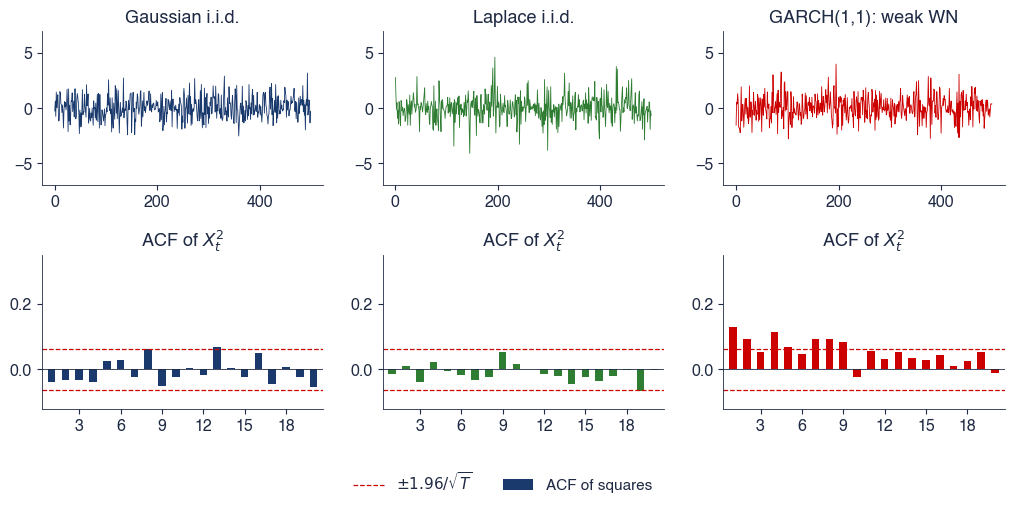

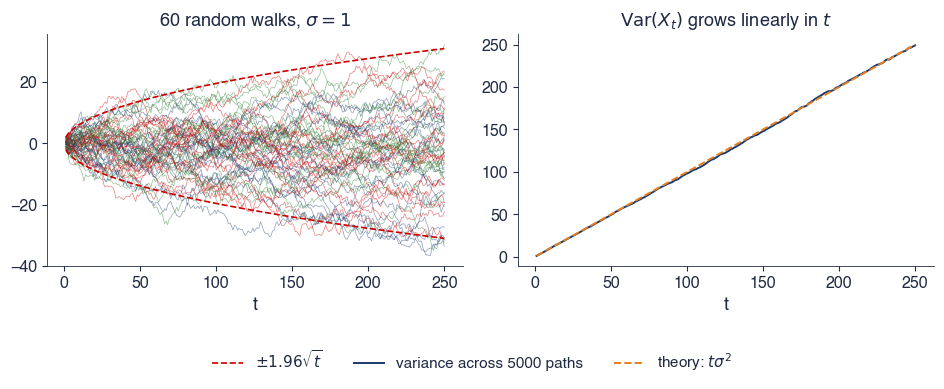

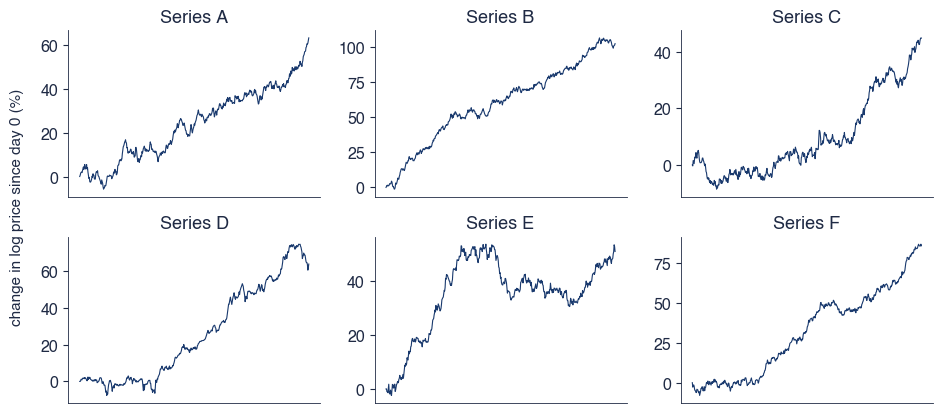

In [9]:
def simulate_garch(n, omega=0.05, alpha=0.10, beta=0.85, burn=500, rng=None):
    """GARCH(1,1) with Normal innovations: a weak white noise (uncorrelated, not independent)."""
    rng = rng if rng is not None else np.random.default_rng(SEED)
    z = rng.normal(size=n + burn)
    e = np.zeros(n + burn)
    s2 = np.full(n + burn, omega / (1 - alpha - beta))
    for t in range(1, n + burn):
        s2[t] = omega + alpha * e[t - 1] ** 2 + beta * s2[t - 1]
        e[t] = np.sqrt(s2[t]) * z[t]
    return e[burn:]


def fig_white_noise(n=1000, save_it=True):
    """Gaussian white noise, i.i.d. Laplace white noise (heavier tails) and GARCH(1,1) weak white noise (variance 1),
    with the ACF of the series and of the squares."""
    rng = np.random.default_rng(SEED + 3)
    w = {'Gaussian i.i.d.': rng.normal(size=n),
         'Laplace i.i.d.': rng.laplace(0, 1 / np.sqrt(2), size=n),
         'GARCH(1,1): weak WN': simulate_garch(n, rng=rng)}
    cols = [st.MainBlue, st.Forest, st.IDAred]
    fig, ax = plt.subplots(2, 3, figsize=(10.4, 4.6))
    out = {}
    for j, ((lab, x), c) in enumerate(zip(w.items(), cols)):
        ax[0, j].plot(x[:500], color=c, lw=0.6)
        ax[0, j].set_title(lab)
        ax[0, j].set_ylim(-7, 7)
        acf_bars(ax[1, j], sample_acf(x ** 2, 20), n, color=c, label='ACF of squares' if j == 0 else '_nolegend_')
        ax[1, j].set_title('ACF of $X_t^2$')
        ax[1, j].set_ylim(-0.12, 0.35)
        out[lab] = {'lb_x': ljung_box(x, 10), 'lb_x2': ljung_box(x ** 2, 10), 'kurt': float(stats.kurtosis(x) + 3)}
    st.fig_legend_bottom(fig, ncol=3, y=-0.01)
    plt.tight_layout()
    save('tsa_ch1_white_noise', save_it)
    return out


def fig_random_walk(n=250, paths=60, nsim=5000, save_it=True):
    """Random walk paths with the +-1.96 sqrt(t) band, and the cross-sectional variance of X_t against t."""
    rng = np.random.default_rng(SEED + 4)
    x = rng.normal(size=(nsim, n)).cumsum(axis=1)
    t = np.arange(1, n + 1)
    fig, ax = plt.subplots(1, 2, figsize=(9.6, 3.4))
    for i in range(paths):
        ax[0].plot(t, x[i], lw=0.5, alpha=0.5, color=st.PALETTE[i % 3], label='_nolegend_')
    ax[0].plot(t, 1.96 * np.sqrt(t), color=st.IDAred, ls='--', lw=1.2, label=r'$\pm 1.96\sqrt{t}$')
    ax[0].plot(t, -1.96 * np.sqrt(t), color=st.IDAred, ls='--', lw=1.2, label='_nolegend_')
    ax[0].set_title(f'{paths} random walks, $\\sigma = 1$')
    ax[0].set_xlabel('t')
    ax[1].plot(t, x.var(axis=0), color=st.MainBlue, label=f'variance across {nsim} paths')
    ax[1].plot(t, t, color=st.Orange, ls='--', label=r'theory: $t\sigma^2$')
    ax[1].set_title(r'$\mathrm{Var}(X_t)$ grows linearly in $t$')
    ax[1].set_xlabel('t')
    st.fig_legend_bottom(fig, ncol=3, y=-0.01)
    plt.tight_layout()
    save('tsa_ch1_random_walk', save_it)
    c = np.corrcoef(x[:, 99], x[:, 109])[0, 1]
    return {'var_end': float(x[:, -1].var()), 'n': n, 'corr_100_110': float(c), 'corr_th': float(np.sqrt(100 / 110)),
            'share_out': float(np.mean(np.abs(x[:, -1]) > 1.96 * np.sqrt(n)))}


def fig_spot_real(k='bet', n=500, save_it=True):
    """Which one is real? The BET log price over its last n days among five random walks with the same drift and
    the same standard deviation of the daily changes."""
    p = np.log(load_close(k)).iloc[-n - 1:]
    r = p.diff().dropna()
    rng = np.random.default_rng(SEED + 5)
    pos = int(rng.integers(0, 6))
    fig, ax = plt.subplots(2, 3, figsize=(9.6, 4.3), sharey=False)
    letters = 'ABCDEF'
    for i, a in enumerate(ax.ravel()):
        if i == pos:
            y = p.values - p.values[0]
        else:
            y = np.r_[0, np.cumsum(r.mean() + r.std() * rng.normal(size=n))]
        a.plot(np.arange(n + 1), 100 * y, color=st.MainBlue, lw=0.8)
        a.set_title(f'Series {letters[i]}')
        a.set_xticks([])
    fig.supylabel('change in log price since day 0 (%)', fontsize=11)
    plt.tight_layout()
    save('tsa_ch1_spot_real', save_it)
    return {'real': letters[pos], 'first': p.index[0].strftime('%Y-%m-%d'), 'last': p.index[-1].strftime('%Y-%m-%d'),
            'mu': float(100 * r.mean()), 'sd': float(100 * r.std()), 'n': n,
            'rho1': float(sample_acf(r, 1)[0]), 'lb10_p': ljung_box(r, 10)['lb_p']}


fig_white_noise(save_it=False)
fig_random_walk(save_it=False)
spot = fig_spot_real(save_it=False)

In [10]:
# the answer
spot

{'real': 'D',
 'first': '2024-09-11',
 'last': '2026-09-18',
 'mu': 0.12734426910214863,
 'sd': 0.9905022647369763,
 'n': 500,
 'rho1': 0.12299743308437527,
 'lb10_p': 0.018079552360704562}

## 5. The lag operator, differencing, Wold and ergodicity

- S&P 500: the log price and its difference.
- Wold weights $\psi_j$ of four processes.
- Running time averages of an ergodic and a non-ergodic process.

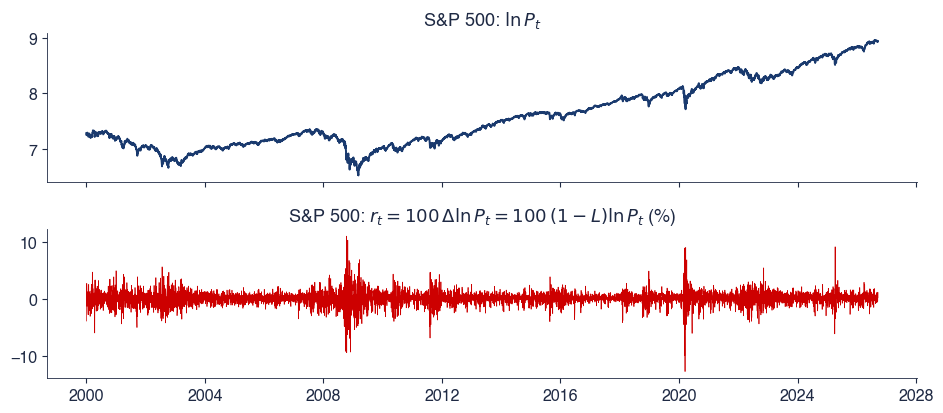

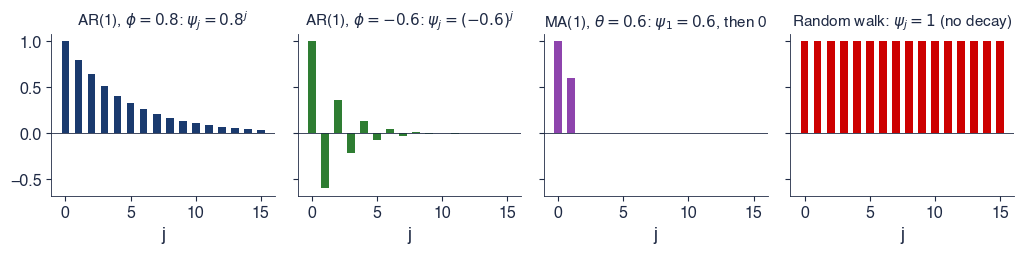

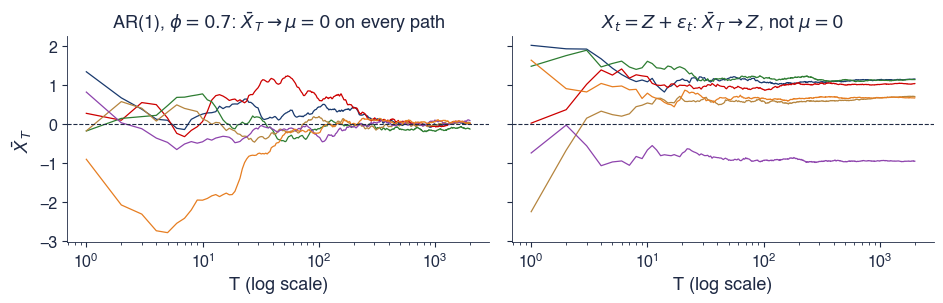

{'a_min': -0.12851033415446592,
 'a_max': 0.08763082944417933,
 'b_min': -0.952728498473659,
 'b_max': 1.156472341296351,
 'z_min': -0.9851279473809644,
 'z_max': 1.1524928222943887,
 'n': 2000}

In [11]:
def fig_sp500_diff(save_it=True):
    """S&P 500: log price (a random-walk-like series) and daily log returns (its first difference)."""
    p = np.log(load_close('sp500', start=START))
    r = 100 * p.diff().dropna()
    fig, ax = plt.subplots(2, 1, figsize=(9.6, 4.3), sharex=True)
    ax[0].plot(p.index, p, color=st.MainBlue)
    ax[0].set_title(r'S&P 500: $\ln P_t$')
    ax[1].plot(r.index, r, color=st.IDAred, lw=0.5)
    ax[1].set_title(r'S&P 500: $r_t = 100\,\Delta \ln P_t = 100\,(1 - L)\ln P_t$ (%)')
    plt.tight_layout()
    save('tsa_ch1_sp500_diff', save_it)
    return {'n': int(len(r)), 'acf1_p': float(sample_acf(p, 1)[0]), 'acf50_p': float(sample_acf(p, 50)[-1]),
            'acf1_r': float(sample_acf(r, 1)[0]), 'mean_r': float(r.mean()), 'sd_r': float(r.std())}


def fig_wold(J=15, save_it=True):
    """Wold weights psi_j of AR(1) (phi = 0.8 and -0.6), MA(1) (theta = 0.6) and of the random walk (psi_j = 1)."""
    j = np.arange(J + 1)
    cases = [(r'AR(1), $\phi = 0.8$: $\psi_j = 0.8^j$', 0.8 ** j, st.MainBlue),
             (r'AR(1), $\phi = -0.6$: $\psi_j = (-0.6)^j$', (-0.6) ** j, st.Forest),
             (r'MA(1), $\theta = 0.6$: $\psi_1 = 0.6$, then 0', np.r_[1, 0.6, np.zeros(J - 1)], st.Purple),
             (r'Random walk: $\psi_j = 1$ (no decay)', np.ones(J + 1), st.IDAred)]
    fig, ax = plt.subplots(1, 4, figsize=(10.4, 2.7), sharey=True)
    for a, (lab, psi, c) in zip(ax, cases):
        a.bar(j, psi, color=c, width=0.6)
        a.axhline(0, color=st.DarkText, lw=0.6)
        a.set_title(lab, fontsize=11)
        a.set_xlabel('j')
    plt.tight_layout()
    save('tsa_ch1_wold', save_it)
    return {'sum_psi2_08': 1 / (1 - 0.64), 'psi5_08': 0.8 ** 5, 'psi10_08': 0.8 ** 10}


def fig_ergodicity(n=2000, paths=6, save_it=True):
    """Running time averages: ergodic AR(1) (all converge to 0) and the non-ergodic X_t = Z + e_t (each path
    converges to its own Z)."""
    rng = np.random.default_rng(SEED + 6)
    t = np.arange(1, n + 1)
    fig, ax = plt.subplots(1, 2, figsize=(9.6, 3.2), sharey=True)
    ends_a, ends_b, zs = [], [], []
    for i in range(paths):
        x = simulate_arma([0.7], n=n, rng=rng)
        ax[0].plot(t, np.cumsum(x) / t, lw=0.9, color=st.PALETTE[i % len(st.PALETTE)])
        ends_a.append(float(x.mean()))
        z = rng.normal()
        y = z + rng.normal(size=n)
        ax[1].plot(t, np.cumsum(y) / t, lw=0.9, color=st.PALETTE[i % len(st.PALETTE)])
        ends_b.append(float(y.mean()))
        zs.append(float(z))
    for a in ax:
        a.axhline(0, color=st.DarkText, ls='--', lw=0.8)
        a.set_xscale('log')
        a.set_xlabel('T (log scale)')
    ax[0].set_title(r'AR(1), $\phi = 0.7$: $\bar X_T \to \mu = 0$ on every path')
    ax[1].set_title(r'$X_t = Z + \varepsilon_t$: $\bar X_T \to Z$, not $\mu = 0$')
    ax[0].set_ylabel(r'$\bar X_T$')
    plt.tight_layout()
    save('tsa_ch1_ergodicity', save_it)
    return {'a_min': min(ends_a), 'a_max': max(ends_a), 'b_min': min(ends_b), 'b_max': max(ends_b),
            'z_min': min(zs), 'z_max': max(zs), 'n': n}


fig_sp500_diff(save_it=False)
fig_wold(save_it=False)
fig_ergodicity(save_it=False)

## 6. Sample ACF and PACF

- Theoretical and sample ACF; the sampling distribution under white noise (Bartlett); ACF and PACF of AR(1), AR(2), MA(1); BET returns, absolute and squared returns.

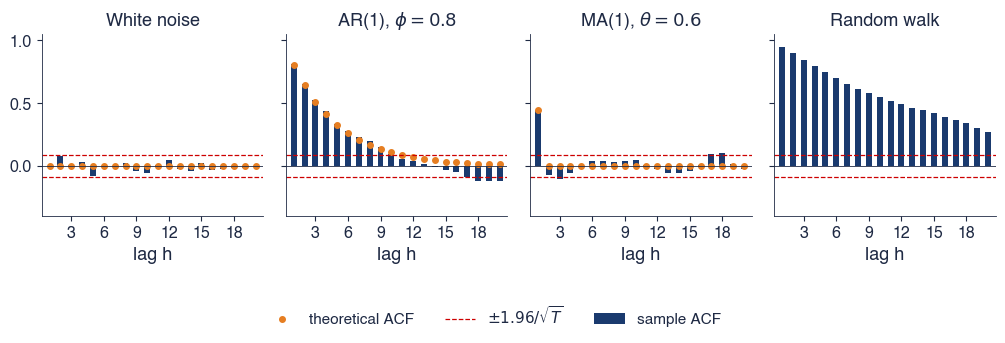

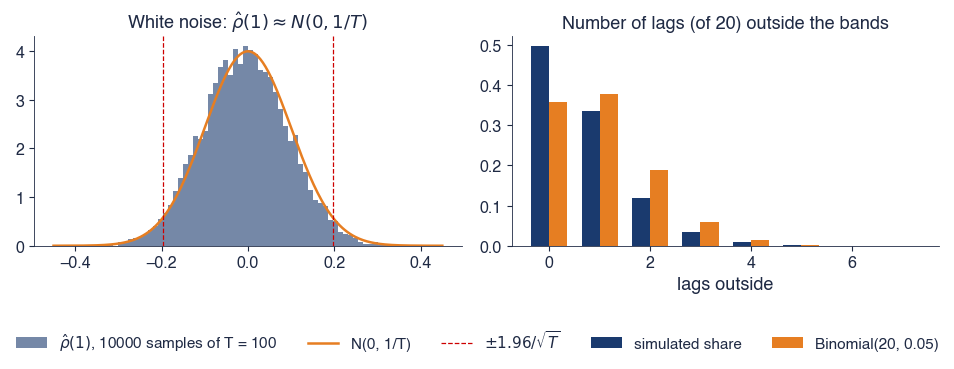

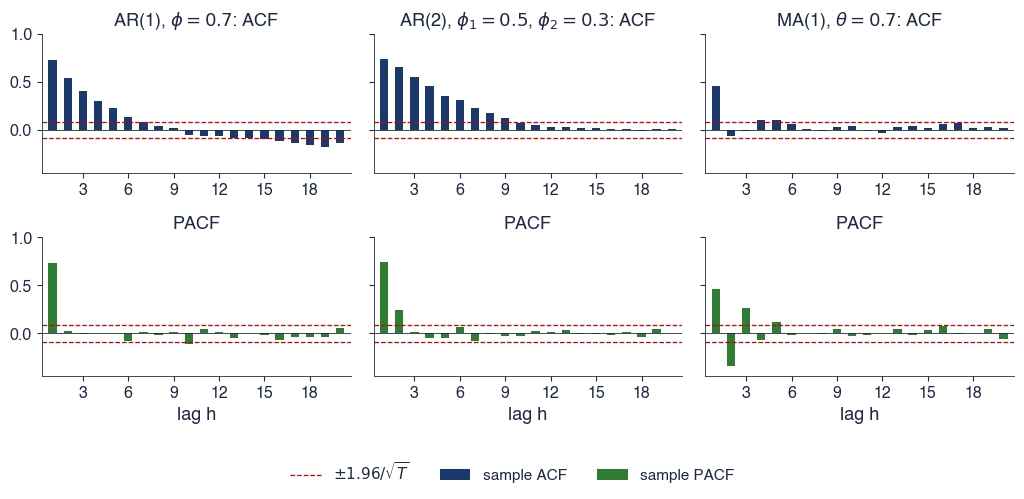

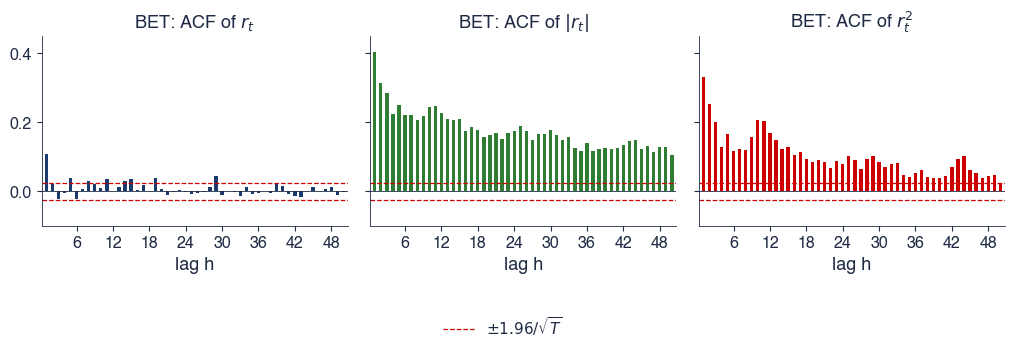

{'n': 6670,
 'first': '2000-01-06',
 'r': {'r1': 0.1088283261694772,
  'r5': 0.03891840936470181,
  'r50': -0.0009447521411234756,
  'lb10': {'lb': 108.01843965612538,
   'lb_p': 1.3381539580012589e-18,
   'bp': 107.94946905891214,
   'bp_p': 1.3816390446114093e-18}},
 'abs': {'r1': 0.40155012562184383,
  'r5': 0.2501373667298849,
  'r50': 0.10641890602244881,
  'lb10': {'lb': 4665.0494195862275,
   'lb_p': 0.0,
   'bp': 4660.545130983565,
   'bp_p': 0.0}},
 'sq': {'r1': 0.33043644577381215,
  'r5': 0.1670668428950652,
  'r50': 0.025282105061247645,
  'lb10': {'lb': 2439.975217306587,
   'lb_p': 0.0,
   'bp': 2437.741181597664,
   'bp_p': 0.0}},
 'band': np.float64(0.02399900047893674)}

In [12]:
def fig_acf_models(n=500, nlags=20, save_it=True):
    """Sample ACF (T = 500) and theoretical ACF of white noise, AR(1) (0.8), MA(1) (0.6) and a random walk."""
    rng = np.random.default_rng(SEED + 7)
    cases = [('White noise', rng.normal(size=n), np.zeros(nlags)),
             (r'AR(1), $\phi = 0.8$', simulate_arma([0.8], n=n, rng=rng), theoretical_acf([0.8], nlags=nlags)),
             (r'MA(1), $\theta = 0.6$', simulate_arma([], [0.6], n=n, rng=rng), theoretical_acf([], [0.6], nlags=nlags)),
             ('Random walk', np.cumsum(rng.normal(size=n)), None)]
    fig, ax = plt.subplots(1, 4, figsize=(10.4, 2.9), sharey=True)
    out = {}
    for i, (a, (lab, x, th)) in enumerate(zip(ax, cases)):
        r = sample_acf(x, nlags)
        acf_bars(a, r, n, theory=th)
        a.set_title(lab)
        a.set_xlabel('lag h')
        out[lab.split(',')[0].replace('$', '')] = {'r1': float(r[0]), 'r2': float(r[1]), 'r10': float(r[9])}
    ax[0].set_ylim(-0.4, 1.05)
    st.fig_legend_bottom(fig, ncol=3, y=-0.03)
    plt.tight_layout()
    save('tsa_ch1_acf_models', save_it)
    out['th_ma1'] = 0.6 / 1.36
    return out


def fig_bartlett(T=100, nsim=10000, nlags=20, save_it=True):
    """Sample ACF of Gaussian white noise: the distribution of rho_hat(1) against N(0, 1/T), and the number of
    lags (out of 20) outside +-1.96/sqrt(T) against the Binomial(20, 0.05) distribution."""
    rng = np.random.default_rng(SEED + 8)
    r1, outside = np.empty(nsim), np.empty(nsim, int)
    b = 1.96 / np.sqrt(T)
    for i in range(nsim):
        x = rng.normal(size=T)
        r = sample_acf(x, nlags)
        r1[i] = r[0]
        outside[i] = int(np.sum(np.abs(r) > b))
    fig, ax = plt.subplots(1, 2, figsize=(9.6, 3.2))
    ax[0].hist(r1, bins=60, density=True, color=st.MainBlue, alpha=0.6, label=rf'$\hat\rho(1)$, {nsim} samples of T = {T}')
    g = np.linspace(-0.45, 0.45, 300)
    ax[0].plot(g, stats.norm.pdf(g, 0, 1 / np.sqrt(T)), color=st.Orange, lw=1.8, label='N(0, 1/T)')
    for s in (-1, 1):
        ax[0].axvline(s * b, color=BAND_COL, ls='--', lw=0.9, label=r'$\pm 1.96/\sqrt{T}$' if s == 1 else '_nolegend_')
    ax[0].set_title(r'White noise: $\hat\rho(1) \approx N(0, 1/T)$')
    k = np.arange(0, 8)
    emp = np.array([np.mean(outside == v) for v in k])
    ax[1].bar(k - 0.18, emp, width=0.36, color=st.MainBlue, label='simulated share')
    ax[1].bar(k + 0.18, stats.binom.pmf(k, nlags, 0.05), width=0.36, color=st.Orange, label='Binomial(20, 0.05)')
    ax[1].set_title('Number of lags (of 20) outside the bands')
    ax[1].set_xlabel('lags outside')
    st.fig_legend_bottom(fig, ncol=5, y=-0.01)
    plt.tight_layout()
    save('tsa_ch1_bartlett', save_it)
    return {'sd_r1': float(r1.std()), 'sd_th': 1 / np.sqrt(T), 'mean_r1': float(r1.mean()), 'mean_th': -1 / T,
            'p_none': float(np.mean(outside == 0)), 'p_none_th': 0.95 ** nlags, 'p_one_plus': float(np.mean(outside >= 1)),
            'mean_out': float(outside.mean()), 'T': T, 'band': b}


def fig_acf_pacf(n=500, nlags=20, save_it=True):
    """Sample ACF and PACF (T = 500) of AR(1) (phi = 0.7), AR(2) (0.5, 0.3) and MA(1) (theta = 0.7)."""
    rng = np.random.default_rng(SEED + 9)
    cases = [(r'AR(1), $\phi = 0.7$', [0.7], []), (r'AR(2), $\phi_1 = 0.5$, $\phi_2 = 0.3$', [0.5, 0.3], []),
             (r'MA(1), $\theta = 0.7$', [], [0.7])]
    fig, ax = plt.subplots(2, 3, figsize=(10.4, 4.5), sharey=True)
    out = {}
    for j, (lab, ph, th) in enumerate(cases):
        x = simulate_arma(ph, th, n=n, rng=rng)
        r, p = sample_acf(x, nlags), sample_pacf(x, nlags)
        acf_bars(ax[0, j], r, n, color=st.MainBlue, label='sample ACF')
        acf_bars(ax[1, j], p, n, color=st.Forest, label='sample PACF')
        ax[0, j].set_title(lab + ': ACF')
        ax[1, j].set_title('PACF')
        ax[1, j].set_xlabel('lag h')
        key = ['ar1', 'ar2', 'ma1'][j]
        out[key] = {'r1': float(r[0]), 'r2': float(r[1]), 'p1': float(p[0]), 'p2': float(p[1]), 'p3': float(p[2])}
    ax[0, 0].set_ylim(-0.45, 1.0)
    st.fig_legend_bottom(fig, ncol=3, y=-0.01)
    plt.tight_layout()
    save('tsa_ch1_acf_pacf', save_it)
    out['ar2_rho1'] = 0.5 / (1 - 0.3)
    out['ar2_rho2'] = 0.5 * 0.5 / (1 - 0.3) + 0.3
    return out


def fig_returns_acf(k='bet', nlags=50, save_it=True):
    """ACF of daily log returns, absolute returns and squared returns (lags 1-50), with Ljung-Box tests."""
    r = log_returns(k, start=START)
    fig, ax = plt.subplots(1, 3, figsize=(10.4, 3.0), sharey=True)
    out = {'n': int(len(r)), 'first': r.index[0].strftime('%Y-%m-%d')}
    for i, (a, (lab, x, c)) in enumerate(zip(ax, [('$r_t$', r, st.MainBlue), (r'$|r_t|$', r.abs(), st.Forest),
                                                  ('$r_t^2$', r ** 2, st.IDAred)])):
        rr = sample_acf(x, nlags)
        acf_bars(a, rr, len(r), color=c, label='_nolegend_')
        a.set_title(f'{NAME.get(k, k)}: ACF of {lab}')
        a.set_xlabel('lag h')
        out[['r', 'abs', 'sq'][i]] = {'r1': float(rr[0]), 'r5': float(rr[4]), 'r50': float(rr[-1]),
                                      'lb10': ljung_box(x, 10)}
    ax[0].set_ylim(-0.1, 0.45)
    st.fig_legend_bottom(fig, ncol=1, y=-0.03)
    plt.tight_layout()
    save(f'tsa_ch1_{k}_acf', save_it)
    out['band'] = 1.96 / np.sqrt(len(r))
    return out


fig_acf_models(save_it=False)
fig_bartlett(save_it=False)
fig_acf_pacf(save_it=False)
fig_returns_acf('bet', save_it=False)

## 7. Portmanteau tests

- Size of Box–Pierce and Ljung–Box in small samples; Ljung–Box statistics of real series.

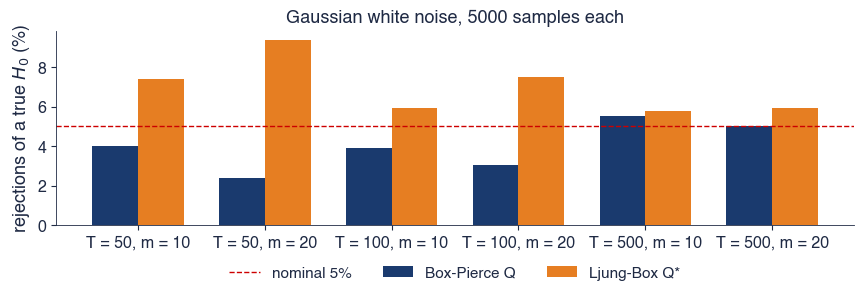

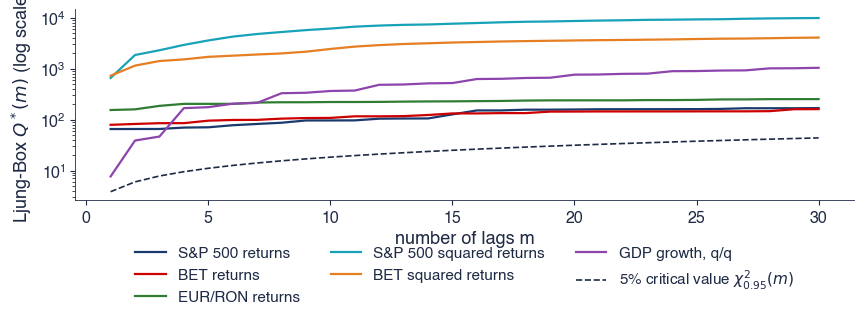

,T,rho1,rho4,Q*(10),p
S&P 500 returns,6714.0,-0.0986,-0.0253,96.2629,0.0
S&P 500 squared returns,6714.0,0.3132,0.3062,6132.8172,0.0
BET returns,6670.0,0.1088,-0.0051,108.0184,0.0
BET squared returns,6670.0,0.3304,0.1270,2439.9752,0.0
EUR/RON returns,5352.0,0.1697,-0.0575,221.6582,0.0
"GDP growth, y/y",122.0,0.6308,0.0328,74.9956,0.0
"GDP growth, q/q",125.0,-0.2444,0.9626,364.7665,0.0
"HICP inflation, m/m",260.0,0.4009,0.1234,126.7075,0.0
Nile flow,100.0,0.4984,0.2392,88.1269,0.0
Sunspots,309.0,0.8202,-0.2758,627.3827,0.0


In [13]:
def lb_size(T=50, m=20, nsim=5000, seed=SEED + 10):
    """Rejection rates at 5% of the Box-Pierce and Ljung-Box tests for Gaussian white noise."""
    rng = np.random.default_rng(seed)
    crit = stats.chi2.ppf(0.95, m)
    rej_bp = rej_lb = 0
    h = np.arange(1, m + 1)
    for _ in range(nsim):
        r = sample_acf(rng.normal(size=T), m)
        q_bp = T * np.sum(r ** 2)
        q_lb = T * (T + 2) * np.sum(r ** 2 / (T - h))
        rej_bp += q_bp > crit
        rej_lb += q_lb > crit
    return rej_bp / nsim, rej_lb / nsim


def fig_lb_size(save_it=True):
    """Size of Box-Pierce and Ljung-Box at the 5% level for T = 50, 100, 500 and m = 10, 20."""
    cases = [(50, 10), (50, 20), (100, 10), (100, 20), (500, 10), (500, 20)]
    res = {f'{T}_{m}': lb_size(T, m) for T, m in cases}
    fig, ax = plt.subplots(figsize=(8.8, 3.2))
    x = np.arange(len(cases))
    ax.bar(x - 0.18, [100 * res[f'{T}_{m}'][0] for T, m in cases], width=0.36, color=st.MainBlue, label='Box-Pierce Q')
    ax.bar(x + 0.18, [100 * res[f'{T}_{m}'][1] for T, m in cases], width=0.36, color=st.Orange, label='Ljung-Box Q*')
    ax.axhline(5, color=BAND_COL, ls='--', lw=1.0, label='nominal 5%')
    ax.set_xticks(x)
    ax.set_xticklabels([f'T = {T}, m = {m}' for T, m in cases])
    ax.set_ylabel('rejections of a true $H_0$ (%)')
    ax.set_title('Gaussian white noise, 5000 samples each')
    st.legend_outside_bottom(ax, ncol=3, y=-0.14)
    plt.tight_layout()
    save('tsa_ch1_lb_size', save_it)
    return {k: {'bp': v[0], 'lb': v[1]} for k, v in res.items()}


def real_series():
    """The real series of the chapter, transformed to (roughly) stationary form."""
    gdp = np.log(ro_gdp('real'))
    hicp = np.log(ro_hicp())
    nile = load_statsmodels('nile')
    return {'S&P 500 returns': log_returns('sp500', start=START),
            'S&P 500 squared returns': log_returns('sp500', start=START) ** 2,
            'BET returns': log_returns('bet', start=START),
            'BET squared returns': log_returns('bet', start=START) ** 2,
            'EUR/RON returns': (100 * np.log(load_close('eurron')).diff()).dropna(),
            'GDP growth, y/y': (100 * gdp.diff(4)).dropna(),
            'GDP growth, q/q': (100 * gdp.diff()).dropna(),
            'HICP inflation, m/m': (100 * hicp.diff())['2005':].dropna(),
            'Nile flow': nile,
            'Sunspots': load_statsmodels('sunspots')}


def fig_lb_stats(m_max=30, save_it=True):
    """Ljung-Box Q*(m), m = 1..30, of six series against the 5% critical value of chi-square(m)."""
    R = real_series()
    keys = ['S&P 500 returns', 'BET returns', 'EUR/RON returns', 'S&P 500 squared returns', 'BET squared returns',
            'GDP growth, q/q']
    cols = [st.MainBlue, st.IDAred, st.Forest, st.Teal, st.Orange, st.Purple]
    m = np.arange(1, m_max + 1)
    fig, ax = plt.subplots(figsize=(8.8, 3.5))
    for k, c in zip(keys, cols):
        q = acorr_ljungbox(np.asarray(R[k], float), lags=list(m), return_df=True)['lb_stat'].values
        ax.plot(m, q, color=c, lw=1.6, label=k)
    ax.plot(m, stats.chi2.ppf(0.95, m), color=st.DarkText, ls='--', lw=1.2, label=r'5% critical value $\chi^2_{0.95}(m)$')
    ax.set_yscale('log')
    ax.set_xlabel('number of lags m')
    ax.set_ylabel('Ljung-Box $Q^*(m)$ (log scale)')
    st.legend_outside_bottom(ax, ncol=3, y=-0.17)
    plt.tight_layout()
    save('tsa_ch1_lb_stats', save_it)
    table = {}
    for k, x in R.items():
        x = np.asarray(x, float)
        r = sample_acf(x, 12)
        table[k] = {'n': int(len(x)), 'r1': float(r[0]), 'r2': float(r[1]), 'r4': float(r[3]), 'r12': float(r[11]),
                    **{f'm{mm}': ljung_box(x, mm) for mm in (10, 20)}}
    pd.DataFrame({k: {'T': v['n'], 'rho1': v['r1'], 'Q*(10)': v['m10']['lb'], 'p': v['m10']['lb_p']}
                  for k, v in table.items()}).T.to_csv(os.path.join(globals().get('OUT_DIR', globals().get('HERE', '.')),
                                                    'ch1_real_series.csv'), float_format='%.4f')
    return table


fig_lb_size(save_it=False)
T = fig_lb_stats(save_it=False)
pd.DataFrame({k: {'T': v['n'], 'rho1': v['r1'], 'rho4': v['r4'], 'Q*(10)': v['m10']['lb'], 'p': v['m10']['lb_p']} for k, v in T.items()}).T.round(4)

## 8. Transformations

- Romanian real GDP: log, quarterly and annual growth; Box–Cox with Guerrero's lambda for nominal GDP; over-differencing.

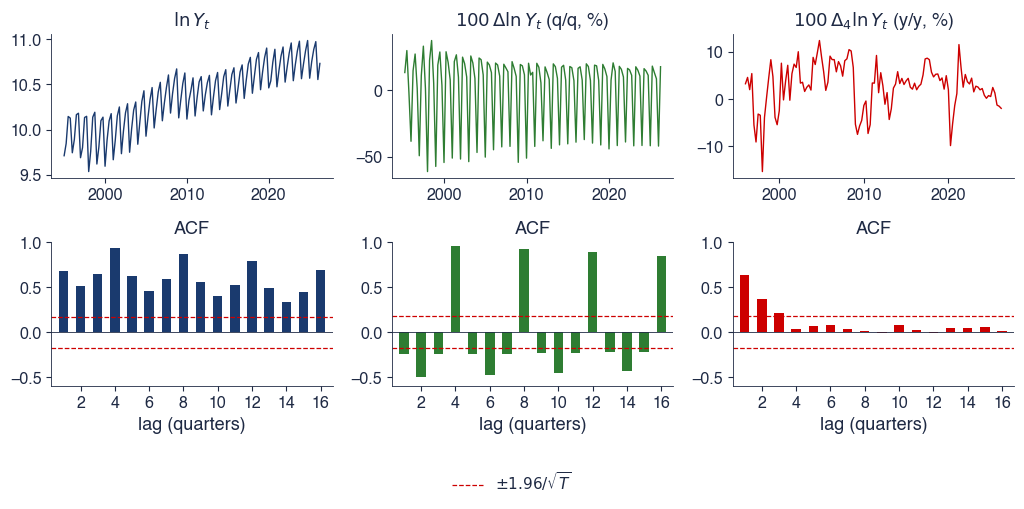

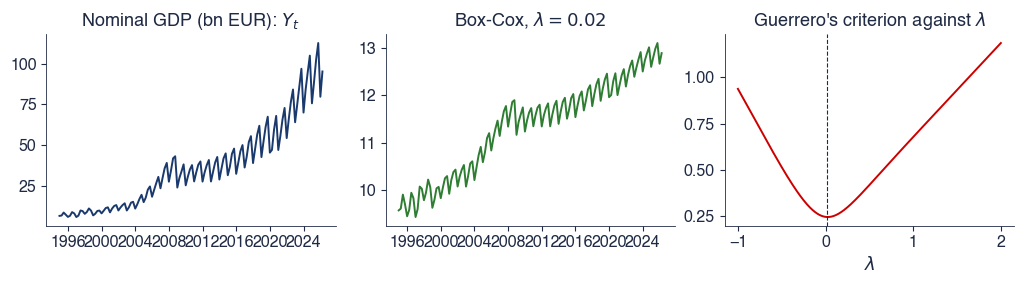

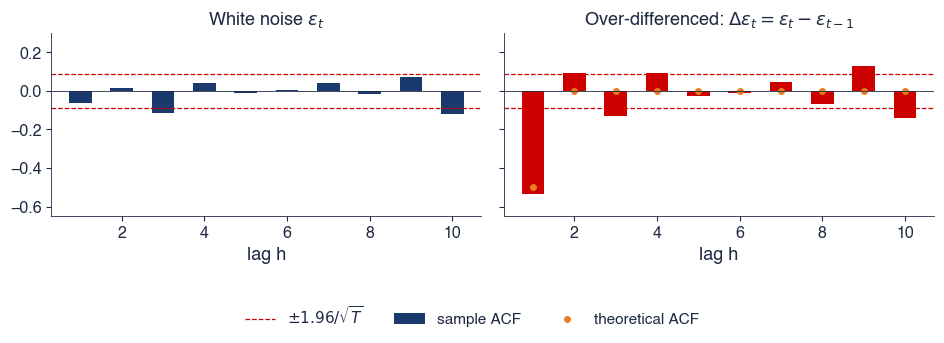

{'r1_e': -0.06156746820804763,
 'r1_d': -0.5355782668102355,
 'var_e': 0.947582603561119,
 'var_d': 2.0114005834735917}

In [14]:
def fig_gdp_transform(nlags=16, save_it=True):
    """Romanian real GDP (not seasonally adjusted): log level, quarterly and annual log differences, and their ACF."""
    g = np.log(ro_gdp('real'))
    d1 = (100 * g.diff()).dropna()
    d4 = (100 * g.diff(4)).dropna()
    fig, ax = plt.subplots(2, 3, figsize=(10.4, 4.6))
    for j, (lab, x, c) in enumerate([(r'$\ln Y_t$', g, st.MainBlue), (r'$100\,\Delta \ln Y_t$ (q/q, %)', d1, st.Forest),
                                     (r'$100\,\Delta_4 \ln Y_t$ (y/y, %)', d4, st.IDAred)]):
        ax[0, j].plot(x.index, x, color=c, lw=1.0)
        ax[0, j].set_title(lab)
        import matplotlib.dates as mdates
        ax[0, j].xaxis.set_major_locator(mdates.YearLocator(10))
        ax[0, j].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        acf_bars(ax[1, j], sample_acf(x, nlags), len(x), color=c, label='_nolegend_')
        ax[1, j].set_title('ACF')
        ax[1, j].set_xlabel('lag (quarters)')
        ax[1, j].set_ylim(-0.6, 1.0)
    st.fig_legend_bottom(fig, ncol=1, y=-0.01)
    plt.tight_layout()
    save('tsa_ch1_gdp_transform', save_it)
    r0, r1, r4 = sample_acf(g, nlags), sample_acf(d1, nlags), sample_acf(d4, nlags)
    covid = d4['2020-04-01'] if pd.Timestamp('2020-04-01') in d4.index else float('nan')
    return {'n': int(len(g)), 'first': g.index[0].strftime('%Y-%m-%d'), 'last': g.index[-1].strftime('%Y-%m-%d'),
            'acf1_level': float(r0[0]), 'acf8_level': float(r0[7]), 'acf1_d1': float(r1[0]), 'acf4_d1': float(r1[3]),
            'acf2_d1': float(r1[1]), 'acf1_d4': float(r4[0]), 'acf4_d4': float(r4[3]), 'mean_d4': float(d4.mean()),
            'sd_d4': float(d4.std()), 'covid_d4': float(covid), 'mean_d1': float(d1.mean()), 'sd_d1': float(d1.std()),
            'last_d4': float(d4.iloc[-1]), 'band': 1.96 / np.sqrt(len(d1))}


def boxcox(y, lam):
    """Box-Cox transform: (y^lam - 1)/lam, or ln y for lam = 0."""
    y = np.asarray(y, float)
    return np.log(y) if abs(lam) < 1e-8 else (y ** lam - 1) / lam


def guerrero_cv(y, lam, period=4):
    """Guerrero (1993): coefficient of variation of sd_i / mean_i^(1 - lam) over non-overlapping blocks of one year."""
    y = np.asarray(y, float)
    nb = len(y) // period
    blocks = y[len(y) - nb * period:].reshape(nb, period)
    ratio = blocks.std(axis=1, ddof=1) / blocks.mean(axis=1) ** (1 - lam)
    return ratio.std(ddof=1) / ratio.mean()


def guerrero_lambda(y, period=4, grid=np.linspace(-1, 2, 301)):
    cv = np.array([guerrero_cv(y, l, period) for l in grid])
    return float(grid[np.argmin(cv)]), grid, cv


def fig_boxcox(save_it=True):
    """Romanian nominal GDP (not seasonally adjusted): the level, the Box-Cox transform with Guerrero's lambda,
    and the Guerrero criterion as a function of lambda."""
    y = ro_gdp('nominal')
    lam, grid, cv = guerrero_lambda(y.values)
    z = pd.Series(boxcox(y.values, lam), index=y.index)
    fig, ax = plt.subplots(1, 3, figsize=(10.4, 3.0))
    ax[0].plot(y.index, y / 1000, color=st.MainBlue)
    ax[0].set_title('Nominal GDP (bn EUR): $Y_t$')
    ax[1].plot(z.index, z, color=st.Forest)
    ax[1].set_title(rf'Box-Cox, $\lambda = {lam:.2f}$')
    ax[2].plot(grid, cv, color=st.IDAred)
    ax[2].axvline(lam, color=st.DarkText, ls='--', lw=0.8)
    ax[2].set_title(r"Guerrero's criterion against $\lambda$")
    ax[2].set_xlabel(r'$\lambda$')
    plt.tight_layout()
    save('tsa_ch1_boxcox', save_it)
    # seasonal amplitude: range within each year, early and late, in levels and after the transform
    yy = y.groupby(y.index.year).agg(lambda s: (s.max() - s.min()) / s.mean() if len(s) == 4 else np.nan).dropna()
    return {'lambda': lam, 'cv_lam': float(cv.min()), 'cv_1': float(guerrero_cv(y.values, 1.0)),
            'cv_0': float(guerrero_cv(y.values, 0.0)), 'first': y.index[0].strftime('%Y-%m-%d'),
            'last': y.index[-1].strftime('%Y-%m-%d'), 'v0': float(y.iloc[0] / 1000), 'v1': float(y.iloc[-1] / 1000),
            'amp_rel_0': float(yy.iloc[:5].mean()), 'amp_rel_1': float(yy.iloc[-5:].mean())}


def fig_overdiff(n=500, nlags=10, save_it=True):
    """Over-differencing: white noise has no autocorrelation; its first difference is an MA(1) with rho(1) = -0.5."""
    rng = np.random.default_rng(SEED + 11)
    e = rng.normal(size=n + 1)
    d = np.diff(e)
    fig, ax = plt.subplots(1, 2, figsize=(9.6, 2.9), sharey=True)
    acf_bars(ax[0], sample_acf(e, nlags), n, color=st.MainBlue, label='sample ACF')
    acf_bars(ax[1], sample_acf(d, nlags), n, color=st.IDAred, theory=np.r_[-0.5, np.zeros(nlags - 1)], label='_nolegend_')
    ax[0].set_title(r'White noise $\varepsilon_t$')
    ax[1].set_title(r'Over-differenced: $\Delta\varepsilon_t = \varepsilon_t - \varepsilon_{t-1}$')
    for a in ax:
        a.set_xlabel('lag h')
    ax[0].set_ylim(-0.65, 0.3)
    st.fig_legend_bottom(fig, ncol=3, y=-0.03)
    plt.tight_layout()
    save('tsa_ch1_overdiff', save_it)
    return {'r1_e': float(sample_acf(e, 1)[0]), 'r1_d': float(sample_acf(d, 1)[0]), 'var_e': float(e.var()),
            'var_d': float(d.var())}


fig_gdp_transform(save_it=False)
fig_boxcox(save_it=False)
fig_overdiff(save_it=False)

## 9. Two classic series: the Nile and the sunspots

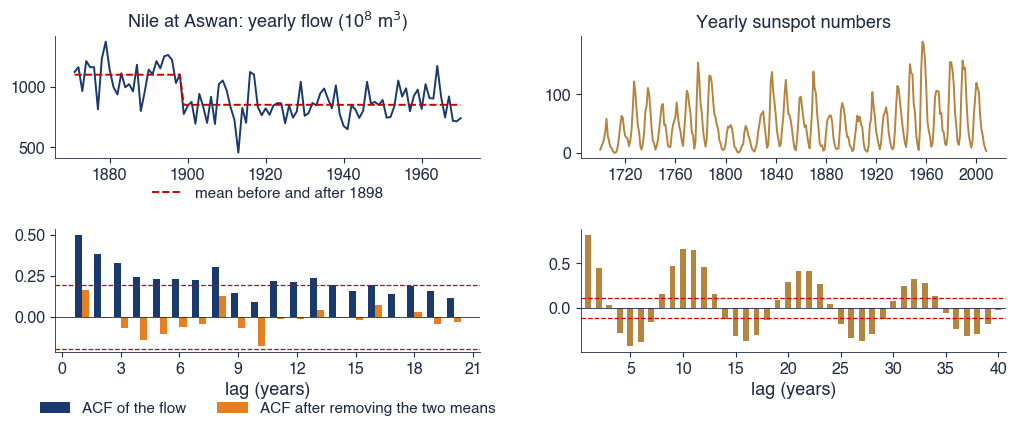

{'m0': 1097.75,
 'm1': 849.9722222222222,
 'r1_nile': 0.4984081841330289,
 'r10_nile': 0.08979141100399479,
 'r1_resid': 0.15985615215706303,
 'n_nile': 100,
 'n_sun': 309,
 'sun_peak_lag': 10,
 'sun_peak': 0.6589800155363378,
 'sun_r1': 0.8202012944200223,
 'sun_min_lag': 5,
 'sun_min': -0.4252394308237747,
 'lb_nile': {'lb': 88.12687155129981,
  'lb_p': 1.2586327670205875e-14,
  'bp': 83.22911521032213,
  'bp_p': 1.1655379396025462e-13},
 'lb_resid': {'lb': 12.973587479579866,
  'lb_p': 0.22515232268370694,
  'bp': 11.961279117432689,
  'bp_p': 0.2876563078940232}}

In [15]:
def fig_textbook(nlags=40, save_it=True):
    """The Nile flow at Aswan (1871-1970, level shift in 1898) and the yearly sunspot numbers (1700-2008),
    with their sample ACF; for the Nile, also the ACF after removing the two means."""
    nile = load_statsmodels('nile')
    sun = load_statsmodels('sunspots')
    brk = pd.Timestamp('1899-01-01')
    m0, m1 = nile[nile.index < brk].mean(), nile[nile.index >= brk].mean()
    resid = nile - np.where(nile.index < brk, m0, m1)
    fig, ax = plt.subplots(2, 2, figsize=(10.4, 4.6))
    ax[0, 0].plot(nile.index, nile, color=st.MainBlue)
    ax[0, 0].plot(nile.index, np.where(nile.index < brk, m0, m1), color=st.IDAred, ls='--', label='mean before and after 1898')
    ax[0, 0].set_title('Nile at Aswan: yearly flow (10$^8$ m$^3$)')
    st.legend_outside_bottom(ax[0, 0], ncol=1, y=-0.12)
    rn, rr = sample_acf(nile, 20), sample_acf(resid, 20)
    lags = np.arange(1, 21)
    ax[1, 0].bar(lags - 0.18, rn, width=0.36, color=st.MainBlue, label='ACF of the flow')
    ax[1, 0].bar(lags + 0.18, rr, width=0.36, color=st.Orange, label='ACF after removing the two means')
    b = 1.96 / np.sqrt(len(nile))
    ax[1, 0].axhline(b, color=BAND_COL, ls='--', lw=0.9)
    ax[1, 0].axhline(-b, color=BAND_COL, ls='--', lw=0.9)
    ax[1, 0].axhline(0, color=st.DarkText, lw=0.6)
    ax[1, 0].set_xlabel('lag (years)')
    ax[1, 0].xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    st.legend_outside_bottom(ax[1, 0], ncol=2, y=-0.3)
    ax[0, 1].plot(sun.index, sun, color=st.Amber)
    ax[0, 1].set_title('Yearly sunspot numbers')
    rs = sample_acf(sun, nlags)
    acf_bars(ax[1, 1], rs, len(sun), color=st.Amber, label='_nolegend_', band=True)
    ax[1, 1].set_xlabel('lag (years)')
    plt.tight_layout()
    save('tsa_ch1_textbook', save_it)
    pk = int(np.argmax(rs[5:15]) + 6)
    return {'m0': float(m0), 'm1': float(m1), 'r1_nile': float(rn[0]), 'r10_nile': float(rn[9]),
            'r1_resid': float(rr[0]), 'n_nile': int(len(nile)), 'n_sun': int(len(sun)), 'sun_peak_lag': pk,
            'sun_peak': float(rs[pk - 1]), 'sun_r1': float(rs[0]), 'sun_min_lag': int(np.argmin(rs[:10]) + 1),
            'sun_min': float(rs[:10].min()), 'lb_nile': ljung_box(nile, 10), 'lb_resid': ljung_box(resid, 10)}


fig_textbook(save_it=False)

## Exercises

1. Repeat the analysis of Section 6 for the DAX (`log_returns('dax')`): is the first-order autocorrelation positive or negative?
2. Compute Guerrero's lambda for Romanian real GDP (`ro_gdp('real')`) and compare it with nominal GDP.
3. Split the Nile series at 1898 and run Ljung–Box on each half.